# Module 2: Epidemic Modeling Template

## Team Members:
Jack Marchesi, Yancy Martinez Alfaro

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

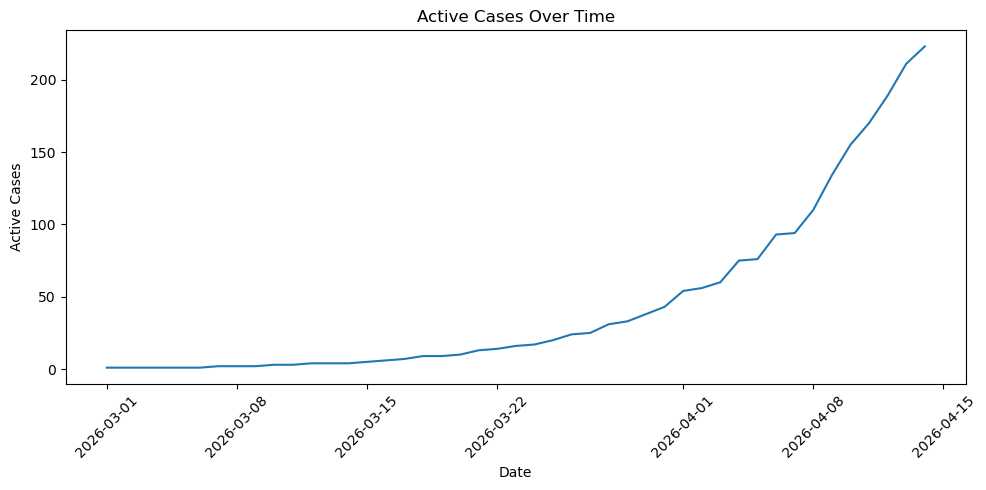

In [8]:
#%%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


#%%
# Load the data
data = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE_1.csv', parse_dates=['date'], header=0, index_col=None)
#data = pd.read_csv(r'C:\Users\yancy\OneDrive\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE_1.csv', parse_dates=['date'], header=0, index_col=None)
data.columns = ['day', 'date', 'active_cases'] # Load the data from the specified CSV file, parsing the 'date' column as datetime objects. The header is set to 0 to indicate that the first row contains column names, and index_col is set to None to use the default integer index. After loading, we rename the columns to 'day', 'date', and 'active_cases' for easier reference in the analysis.

#%%
# Make a plot of the active cases over time

plt.figure(figsize=(10, 5)) #creating a plot of the active cases over time
plt.plot(data['date'], data['active_cases'])
plt.xlabel('Date')
plt.ylabel('Active Cases')
plt.title('Active Cases Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Question 1: I notice that the initial infections spread very slow, taking 7 days for the second person to be infected, and another 3 for a third person.
Question 2: We can use the line of best fit and find least squared values to match the exponential growth.
Question 3: The beta, gamma, and sigma values.

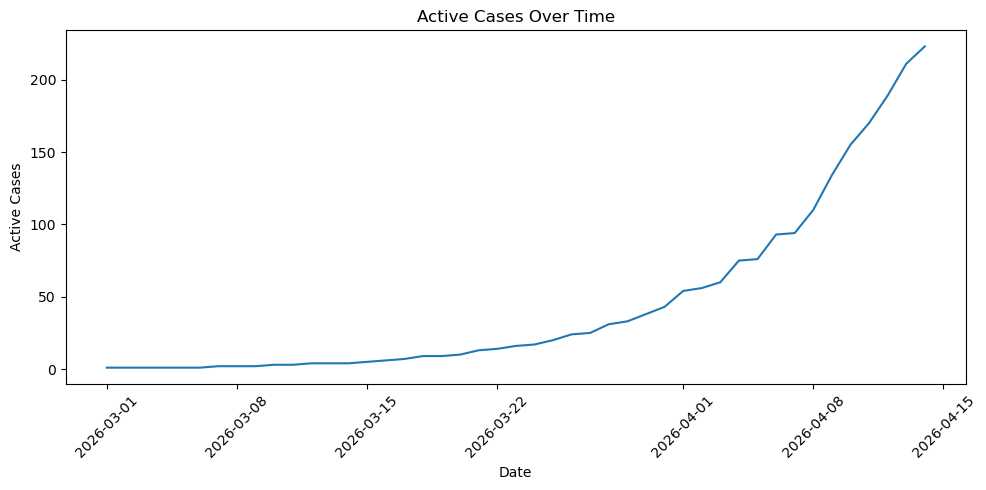

lambda = 0.1300 per day
doubling time = 5.3 days
R0 estimate = 1.91 (assuming 7 day infectious period)


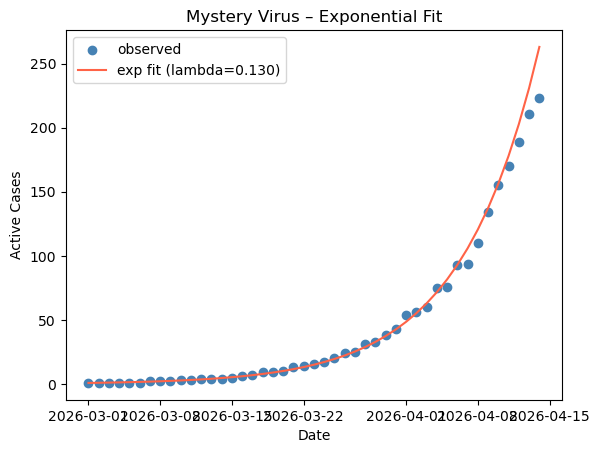

In [2]:
#%%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
#%%
# Load the data
data = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE_1.csv', parse_dates=['date'], header=0, index_col=None)
# data = pd.read_csv('../Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)
#%%
data.columns = ['day', 'date', 'active_cases']

# We have day number, date, and active cases. We can use the day number and active cases to fit an exponential growth curve to estimate R0.
# Let's define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fit the exponential growth model to the data. 
# We'll use a handy function from scipy called CURVE_FIT that allows us to fit any given function to our data. 
# We will fit the exponential growth function to the active cases data. HINT: Look up the documentation for curve_fit to see how to use it.

# Approximate R0 using this fit

# Add the fit as a line on top of your scatterplot.

plt.figure(figsize=(10, 5)) #creating a plot of the active cases over time
plt.plot(data['date'], data['active_cases'])
plt.xlabel('Date')
plt.ylabel('Active Cases')
plt.title('Active Cases Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

growth = data[(data['day'] >= 7) & (data['day'] <= 40)] # growth is used to select the data from day 7 to day 40, which is the period of exponential growth
coefficients = np.polyfit(growth['day'], np.log(growth['active_cases']), 1) # np.polyfit is used to fit a line to the log of the active cases, which gives us the growth rate (lambda) as the slope of the line
lambd = coefficients[0] # the growth rate (lambda) is the first coefficient returned by np.polyfit, which is the slope of the line fitted to the log of the active cases
print(f'lambda = {lambd:.4f} per day') # print the growth rate (lambda) in per day units
print(f'doubling time = {np.log(2)/lambd:.1f} days') # the doubling time is calculated as the natural log of 2 divided by the growth rate (lambda), which gives us the time it takes for the number of active cases to double

# we assumed infectious period of 7 days to get R0 (given 1/7 was the number given in the slides for gamma, the recovery rate)
gamma = 1/7
R0 = (lambd + gamma) / gamma # R0 = (lambda + gamma) / gamma, where lambda is the growth rate and gamma is the recovery rate. This formula comes from the SIR model, where R0 represents the average number of secondary infections produced by a single infected individual in a completely susceptible population.
print(f'R0 estimate = {R0:.2f} (assuming 7 day infectious period)') #print the estimated R0 value, rounded to 2 decimal places


t_fit = np.arange(1, 46) # t_fit is an array of time points from day 1 to day 45, which we will use to plot the exponential fit of the active cases over time. This range is chosen to cover the period of exponential growth and a few days beyond it for visualization purposes.
I_fit = np.exp(coefficients[1] + lambd * t_fit) # I_fit is the exponential fit of the active cases over time, calculated using the coefficients from the linear fit to the log of the active cases. The formula used is I(t) = exp(intercept + lambda * t), where intercept is the second coefficient returned by np.polyfit (the y-intercept of the line fitted to the log of the active cases) and lambda is the growth rate. This gives us the predicted number of active cases at each time point in t_fit based on the exponential growth model.
dates_fit = data['date'].min() + pd.to_timedelta(t_fit - 1, unit='D') # dates_fit is an array of dates corresponding to the time points in t_fit.  The time delta is calculated as (t_fit - 1) days, which means that the first time point (t=1) corresponds to the minimum date, and subsequent time points correspond to subsequent days. This allows us to plot the exponential fit against the actual dates of the observed active cases.

plt.scatter(data['date'], data['active_cases'], color='steelblue', label='observed') # create a scatter plot of the observed active cases over time, with the dates on the x-axis and the number of active cases on the y-axis. The points are colored steelblue and labeled as 'observed' for the legend.
plt.plot(dates_fit, I_fit, color='tomato', label=f'exp fit (lambda={lambd:.3f})')
plt.xlabel('Date')
plt.ylabel('Active Cases')
plt.title('Mystery Virus – Exponential Fit')
plt.legend()
plt.savefig('active_cases_with_exponential_fit.png')
plt.show()




Question 1: Our R0 value was 1.91, which closely matches rabies. Rabies is a viral disease that is spread through salivaand open wounds/blood. Rabies is very deadly, with death being certain after symptoms appear. There are vaccines that exist to prevent rabies.
Question 2: I think the R0 is relatively accurate, but could possibly be more accurate with more data points.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

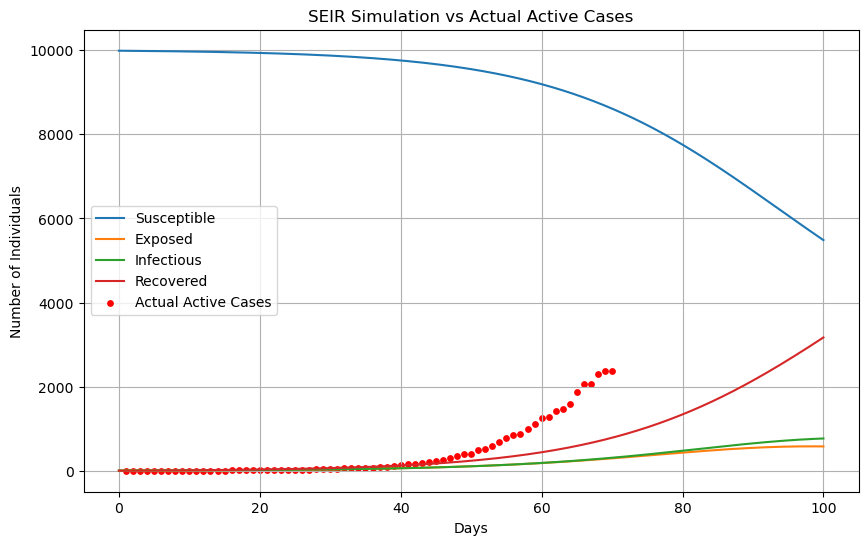

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(r'C:\Users\yancy\OneDrive\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#2.csv')
data.columns = ['day', 'date', 'active_cases']
cases = data['active_cases']
days_data = data['day']


#model parameters
beta = 0.27   # Infection rate estimates from R0
sigma = 1/5   # Rate exposed people became infectious
gamma = 1/7   # Recovery rate estimates from R0

N = 10000      # Total population size
num_days = 100    # Number of days to simulate
dt = 0.1       # Time step for the simulation (1 day)

# initial populations
S = [9990]  # Initial susceptible population
E = [5]    # Initial exposed population
I = [5]    # Initial infectious population
R = [0]    # Initial recovered population

# Euler method simulation

# for day in range(num_days):
num_steps = int(num_days / dt)
for _ in range(num_steps):
    #Get the most recent values
    s = S[-1]
    e = E[-1]
    i = I[-1]
    r = R[-1]
    # Calculate the changes
    ds = -beta * s * i / N   # Change in susceptible population
    de = beta * s * i / N - sigma * e  # Change in exposed population
    di = sigma * e - gamma * i  # Change in infectious population
    dr = gamma * i  # Change in recovered population

#     #Euler update step: next value = current value + change * time step
    S.append(s + ds * dt)
    E.append(e + de * dt)
    I.append(i + di * dt)
    R.append(r + dr * dt)

    # Avoid negative populations
    S[-1] = max(S[-1], 0)
    E[-1] = max(E[-1], 0)
    I[-1] = max(I[-1], 0)
    R[-1] = max(R[-1], 0)

# --- Time array for plotting ---
t = np.linspace(0, num_days, len(S))

# --- Plot SEIR simulation ---
plt.figure(figsize=(10,6))
plt.plot(t, S, label='Susceptible')
plt.plot(t, E, label='Exposed')
plt.plot(t, I, label='Infectious')
plt.plot(t, R, label='Recovered')

# --- Overlay actual data ---
plt.scatter(days_data, cases, color='red', label='Actual Active Cases', s=15)

plt.xlabel('Days')
plt.ylabel('Number of Individuals')
plt.title('SEIR Simulation vs Actual Active Cases')
plt.legend()
plt.grid(True)
plt.show()



### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

Fitted parameters: beta=0.2014, sigma=0.0943, gamma=0.0064


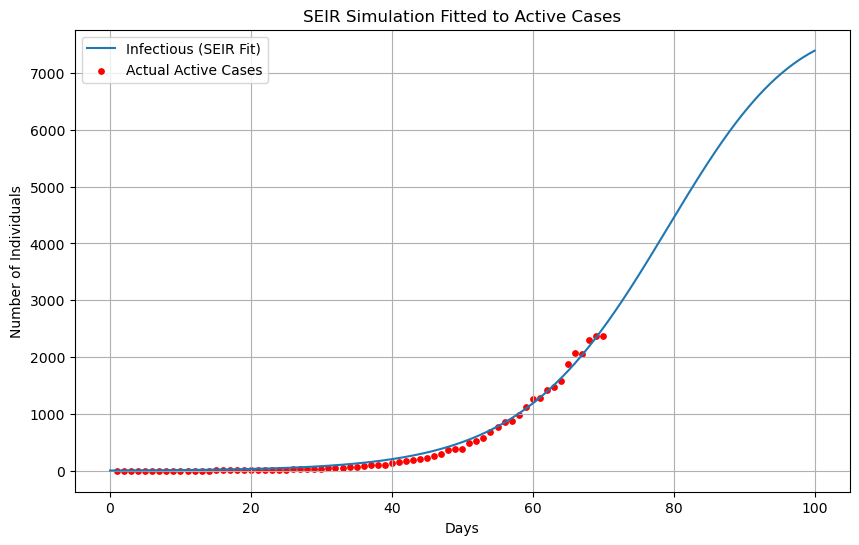

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

#Load data
data = pd.read_csv(r'C:\Users\yancy\OneDrive\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#2.csv')
data.columns = ['day', 'date', 'active_cases']
cases = data['active_cases'].values
days_data = data['day'].values

#Initial populations and parameters
N = 10000
S0, E0, I0, R0 = 9990, 5, 5, 0
num_days = 100
dt = 0.1

#SEIR simulation function
def simulate_seir(params):
    beta, sigma, gamma = params
    S, E, I, R = [S0], [E0], [I0], [R0]
    for _ in range(int(num_days/dt)):
        s, e, i, r = S[-1], E[-1], I[-1], R[-1]
        ds = -beta * s * i / N
        de = beta * s * i / N - sigma * e
        di = sigma * e - gamma * i
        dr = gamma * i
        S.append(max(s + ds*dt,0))
        E.append(max(e + de*dt,0))
        I.append(max(i + di*dt,0))
        R.append(max(r + dr*dt,0))
    return np.array(I)

#Objective function: least squares difference between simulated infectious and actual cases
def objective(params):
    I_sim = simulate_seir(params)
    t_sim = np.linspace(0, num_days, len(I_sim))
    I_interp = np.interp(days_data, t_sim, I_sim)
    return np.sum((I_interp - cases)**2)

#Fit parameters
res = minimize(objective, [0.27, 1/5, 1/7], bounds=[(0,1),(0,1),(0,1)]) # Use the minimize function from scipy to find the parameters (beta, sigma, gamma) that minimize the objective function. The initial guess for the parameters is [0.27, 1/5, 1/7], and we set bounds to ensure that the parameters stay within a reasonable range (0 to 1).
beta_fit, sigma_fit, gamma_fit = res.x # Extract the fitted parameters from the optimization result
print(f"Fitted parameters: beta={beta_fit:.4f}, sigma={sigma_fit:.4f}, gamma={gamma_fit:.4f}")

#Run simulation with fitted parameters
I_fit = simulate_seir([beta_fit, sigma_fit, gamma_fit])

#Time array for plotting the fit
t = np.linspace(0, num_days, len(I_fit))

# plot the graph
plt.figure(figsize=(10,6))
plt.plot(t, I_fit, label='Infectious (SEIR Fit)')
plt.scatter(days_data, cases, color='red', label='Actual Active Cases', s=15)
plt.xlabel('Days')
plt.ylabel('Number of Individuals')
plt.title('SEIR Simulation Fitted to Active Cases')
plt.legend()
plt.grid(True)
plt.show()


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

Fitted parameters: beta=0.2014, sigma=0.0943, gamma=0.0064


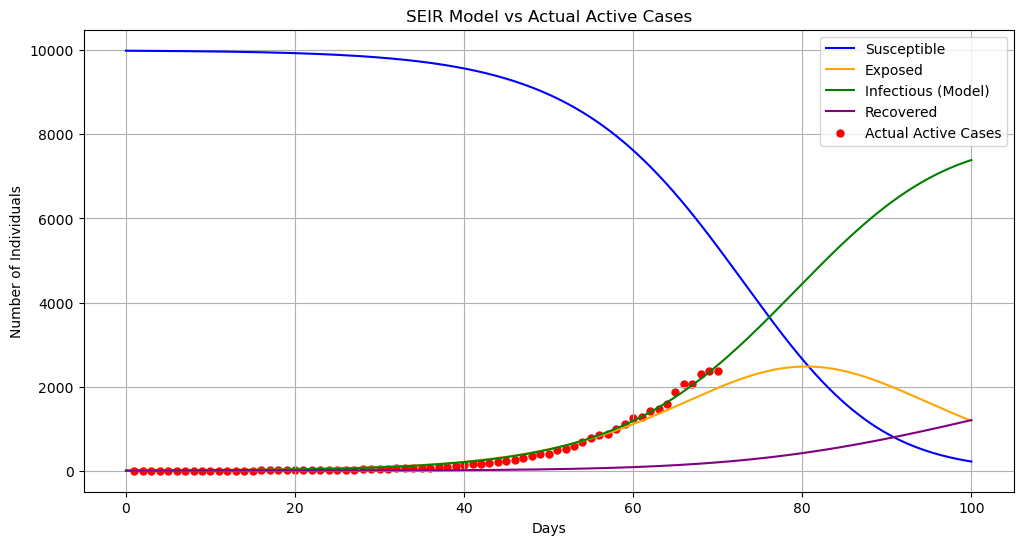

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

data = pd.read_csv(
    r'C:\Users\yancy\OneDrive\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#2.csv'
)
data.columns = ['day', 'date', 'active_cases']  # rename columns
cases = data['active_cases'].values  # number of infected people each day
days_data = data['day'].values       # day numbers

# Model parameters and initial conditions
N = 10000        # Total population
S0 = 9990        # Initially susceptible
E0 = 5           # Initially exposed
I0 = 5           # Initially infectious
R0 = 0           # Initially recovered
num_days = 100   # How many days to simulate
dt = 0.1         # Time step (fraction of a day)

# SEIR simulation function
def simulate_seir(params):
    """
    Simulates the SEIR model given beta, sigma, gamma.
    Returns arrays for S, E, I, R over time.
    """
    beta, sigma, gamma = params
    
    # Initialize lists to store each compartment
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    
    # Loop over time steps
    for _ in range(int(num_days/dt)):
        s, e, i, r = S[-1], E[-1], I[-1], R[-1]  # current values
        
        # SEIR equations
        ds = -beta * s * i / N           # change in susceptible
        de = beta * s * i / N - sigma*e  # change in exposed
        di = sigma*e - gamma*i           # change in infectious
        dr = gamma*i                     # change in recovered
        
        # Update values using Euler method and prevent negative numbers
        S.append(max(s + ds*dt, 0))
        E.append(max(e + de*dt, 0))
        I.append(max(i + di*dt, 0))
        R.append(max(r + dr*dt, 0))
    
    # Convert lists to arrays for easier handling
    return np.array(S), np.array(E), np.array(I), np.array(R)

# Objective function to minimize
def objective(params):
    """
    Computes the difference between the model-predicted infections (I)
    and the actual active cases. This is what we want to minimize.
    """
    _, _, I_sim, _ = simulate_seir(params)
    
    # Create time array for the simulation
    t_sim = np.linspace(0, num_days, len(I_sim))
    
    # Interpolate the simulation to match the actual data days
    I_interp = np.interp(days_data, t_sim, I_sim)
    
    # Return sum of squared differences (least squares)
    return np.sum((I_interp - cases)**2)

# Fit parameters using scipy.optimize.minimize

initial_guess = [0.27, 1/5, 1/7]

# Use scipy.optimize.minimize to find the best-fitting parameters
res = minimize(objective, initial_guess, bounds=[(0,1),(0,1),(0,1)])

# Extract the fitted parameters
beta_fit, sigma_fit, gamma_fit = res.x
print(f"Fitted parameters: beta={beta_fit:.4f}, sigma={sigma_fit:.4f}, gamma={gamma_fit:.4f}")

# Run the SEIR simulation with the fitted parameters to get the predicted number of infectious individuals over time
S_fit, E_fit, I_fit, R_fit = simulate_seir([beta_fit, sigma_fit, gamma_fit])
t = np.linspace(0, num_days, len(S_fit))  # time array for plotting

# Plot SEIR simulation fitted to active cases
plt.figure(figsize=(12,6))

# Plot SEIR compartments
plt.plot(t, S_fit, label='Susceptible', color='blue')
plt.plot(t, E_fit, label='Exposed', color='orange')
plt.plot(t, I_fit, label='Infectious (Model)', color='green')
plt.plot(t, R_fit, label='Recovered', color='purple')

# Overlay actual active cases as red dots
plt.scatter(days_data, cases, color='red', label='Actual Active Cases', s=25)

# Add labels and title
plt.xlabel('Days')
plt.ylabel('Number of Individuals')
plt.title('SEIR Model vs Actual Active Cases')

# Show legend and grid
plt.legend()
plt.grid(True)
plt.show()


### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


Fitted parameters: beta=0.2014, sigma=0.0943, gamma=0.0064
Peak infections: 7390
Day of peak infections: 100.0


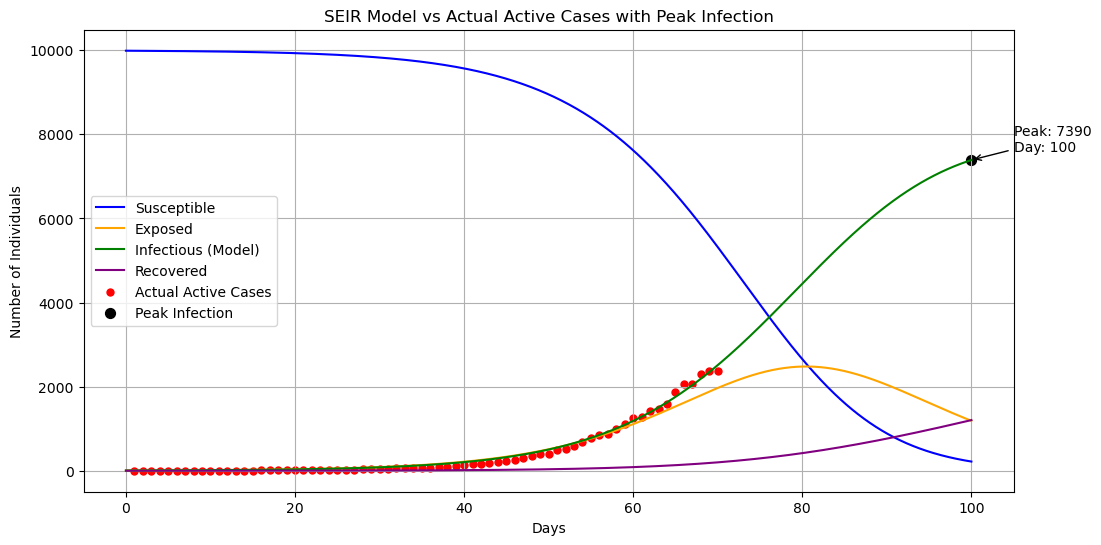

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Load the data
data = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#2.csv', parse_dates=['date'], header=0, index_col=None)
#data = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#@.csv', parse_dates=['date'], header=0, index_col=None)
#data = pd.read_csv(
#    r'C:\Users\yancy\OneDrive\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#2.csv'
#)
data.columns = ['day', 'date', 'active_cases']  # rename columns
cases = data['active_cases'].values  # number of infected people each day
days_data = data['day'].values       # day numbers

# Model parameters and initial conditions
N = 10000        # Total population
S0 = 9990        # Initially susceptible
E0 = 5           # Initially exposed
I0 = 5           # Initially infectious
R0 = 0           # Initially recovered
num_days = 100   # Number of days to simulate
dt = 0.1         # Time step (fraction of a day)

# SEIR simulation function
def simulate_seir(params):
    """
    Simulates the SEIR model given beta, sigma, gamma.
    Returns arrays for S, E, I, R over time.
    """
    beta, sigma, gamma = params
    
    # Initialize lists to store each compartment
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    
    # Loop over time steps
    for _ in range(int(num_days/dt)):
        s, e, i, r = S[-1], E[-1], I[-1], R[-1]  # current values
        
        # SEIR equations
        ds = -beta * s * i / N           # change in susceptible
        de = beta * s * i / N - sigma*e  # change in exposed
        di = sigma*e - gamma*i           # change in infectious
        dr = gamma*i                     # change in recovered
        
        # Update values using Euler method and prevent negative numbers
        S.append(max(s + ds*dt, 0))
        E.append(max(e + de*dt, 0))
        I.append(max(i + di*dt, 0))
        R.append(max(r + dr*dt, 0))
    
    # Convert lists to arrays for easier handling
    return np.array(S), np.array(E), np.array(I), np.array(R)

# Objective function to minimize
def objective(params):
    """
    Computes the difference between model-predicted infections (I)
    and actual active cases. This is what we want to minimize.
    """
    _, _, I_sim, _ = simulate_seir(params)
    
    # Create time array for the simulation
    t_sim = np.linspace(0, num_days, len(I_sim))
    
    # Interpolate the simulation to match the actual data days
    I_interp = np.interp(days_data, t_sim, I_sim)
    
    # Return sum of squared differences (least squares)
    return np.sum((I_interp - cases)**2)

# Fit parameters using scipy.optimize.minimize
initial_guess = [0.27, 1/5, 1/7]  # starting guesses for beta, sigma, gamma
res = minimize(objective, initial_guess, bounds=[(0,1),(0,1),(0,1)])
beta_fit, sigma_fit, gamma_fit = res.x
print(f"Fitted parameters: beta={beta_fit:.4f}, sigma={sigma_fit:.4f}, gamma={gamma_fit:.4f}")

# Run the SEIR simulation with the fitted parameters to get the predicted number of infectious individuals over time
S_fit, E_fit, I_fit, R_fit = simulate_seir([beta_fit, sigma_fit, gamma_fit])
t = np.linspace(0, num_days, len(S_fit))  # time array for plotting

# Analyze the peak of infections
peak_infections = np.max(I_fit)             # maximum number of infectious people
peak_index = np.argmax(I_fit)               # index of the peak
peak_day = t[peak_index]                    # convert index to day

print(f"Peak infections: {peak_infections:.0f}")
print(f"Day of peak infections: {peak_day:.1f}")

# Plot SEIR simulation fitted to active cases with peak annotation
plt.figure(figsize=(12,6))

# Plot SEIR compartments
plt.plot(t, S_fit, label='Susceptible', color='blue')
plt.plot(t, E_fit, label='Exposed', color='orange')
plt.plot(t, I_fit, label='Infectious (Model)', color='green')
plt.plot(t, R_fit, label='Recovered', color='purple')

# Overlay actual active cases as red dots
plt.scatter(days_data, cases, color='red', label='Actual Active Cases', s=25)

# Mark and annotate the peak infection
plt.scatter(peak_day, peak_infections, color='black', s=50, label='Peak Infection')
plt.annotate(
    f'Peak: {int(peak_infections)}\nDay: {int(peak_day)}',
    xy=(peak_day, peak_infections),
    xytext=(peak_day+5, peak_infections+200),
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=10
)

# Labels, title, legend
plt.xlabel('Days')
plt.ylabel('Number of Individuals')
plt.title('SEIR Model vs Actual Active Cases with Peak Infection')
plt.legend()
plt.grid(True)
plt.show()


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


Fitted parameters: beta=0.2890, sigma=0.1413, gamma=0.0655
Peak infections: 2889
Day of peak infections: 80.7


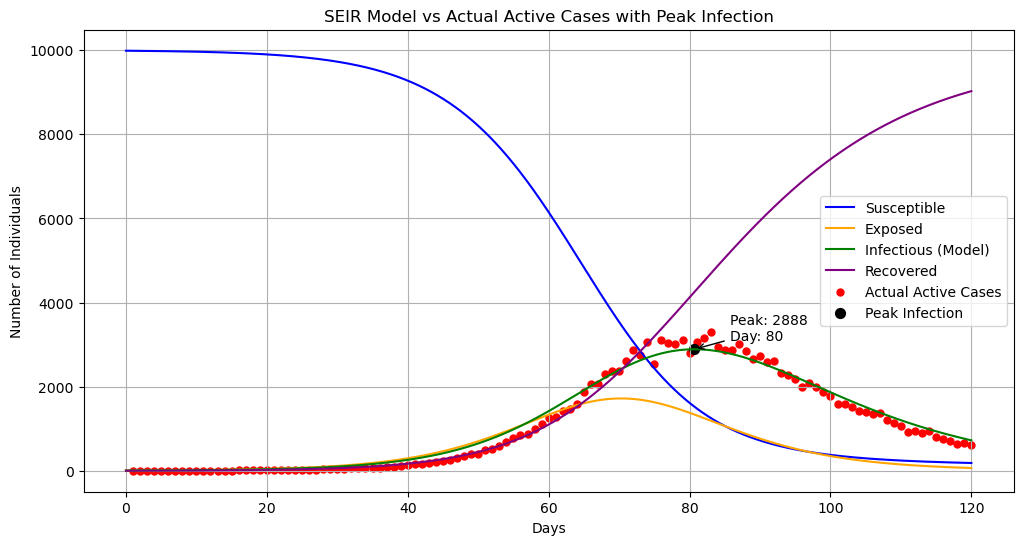

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Load the data
data = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)
#data = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#@.csv', parse_dates=['date'], header=0, index_col=None)
#data = pd.read_csv(
#    r'C:\Users\yancy\OneDrive\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#2.csv'
#)
data.columns = ['day', 'date', 'active_cases']  # rename columns
cases = data['active_cases'].values  # number of infected people each day
days_data = data['day'].values       # day numbers

# Model parameters and initial conditions
N = 10000        # Total population
S0 = 9990        # Initially susceptible
E0 = 5           # Initially exposed
I0 = 5           # Initially infectious
R0 = 0           # Initially recovered
num_days = 120   # Number of days to simulate
dt = 0.1         # Time step (fraction of a day)

# SEIR simulation function
def simulate_seir(params):
    """
    Simulates the SEIR model given beta, sigma, gamma.
    Returns arrays for S, E, I, R over time.
    """
    beta, sigma, gamma = params
    
    # Initialize lists to store each compartment
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    
    # Loop over time steps
    for _ in range(int(num_days/dt)):
        s, e, i, r = S[-1], E[-1], I[-1], R[-1]  # current values
        
        # SEIR equations
        ds = -beta * s * i / N           # change in susceptible
        de = beta * s * i / N - sigma*e  # change in exposed
        di = sigma*e - gamma*i           # change in infectious
        dr = gamma*i                     # change in recovered
        
        # Update values using Euler method and prevent negative numbers
        S.append(max(s + ds*dt, 0))
        E.append(max(e + de*dt, 0))
        I.append(max(i + di*dt, 0))
        R.append(max(r + dr*dt, 0))
    
    # Convert lists to arrays for easier handling
    return np.array(S), np.array(E), np.array(I), np.array(R)

# Objective function to minimize
def objective(params):
    """
    Computes the difference between model-predicted infections (I)
    and actual active cases. This is what we want to minimize.
    """
    _, _, I_sim, _ = simulate_seir(params)
    
    # Create time array for the simulation
    t_sim = np.linspace(0, num_days, len(I_sim))
    
    # Interpolate the simulation to match the actual data days
    I_interp = np.interp(days_data, t_sim, I_sim)
    
    # Return sum of squared differences (least squares)
    return np.sum((I_interp - cases)**2)

# Fit parameters using scipy.optimize.minimize
initial_guess = [0.27, 1/5, 1/7]  # starting guesses for beta, sigma, gamma
res = minimize(objective, initial_guess, bounds=[(0,1),(0,1),(0,1)])
beta_fit, sigma_fit, gamma_fit = res.x
print(f"Fitted parameters: beta={beta_fit:.4f}, sigma={sigma_fit:.4f}, gamma={gamma_fit:.4f}")

# Run the SEIR simulation with the fitted parameters to get the predicted number of infectious individuals over time
S_fit, E_fit, I_fit, R_fit = simulate_seir([beta_fit, sigma_fit, gamma_fit])
t = np.linspace(0, num_days, len(S_fit))  # time array for plotting

# Analyze the peak of infections
peak_infections = np.max(I_fit)             # maximum number of infectious people
peak_index = np.argmax(I_fit)               # index of the peak
peak_day = t[peak_index]                    # convert index to day

print(f"Peak infections: {peak_infections:.0f}")
print(f"Day of peak infections: {peak_day:.1f}")

# Plot SEIR simulation fitted to active cases with peak annotation
plt.figure(figsize=(12,6))

# Plot SEIR compartments
plt.plot(t, S_fit, label='Susceptible', color='blue')
plt.plot(t, E_fit, label='Exposed', color='orange')
plt.plot(t, I_fit, label='Infectious (Model)', color='green')
plt.plot(t, R_fit, label='Recovered', color='purple')

# Overlay actual active cases as red dots
plt.scatter(days_data, cases, color='red', label='Actual Active Cases', s=25)

# Mark and annotate the peak infection
plt.scatter(peak_day, peak_infections, color='black', s=50, label='Peak Infection')
plt.annotate(
    f'Peak: {int(peak_infections)}\nDay: {int(peak_day)}',
    xy=(peak_day, peak_infections),
    xytext=(peak_day+5, peak_infections+200),
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=10
)

# Labels, title, legend
plt.xlabel('Days')
plt.ylabel('Number of Individuals')
plt.title('SEIR Model vs Actual Active Cases with Peak Infection')
plt.legend()
plt.grid(True)
plt.show()

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



Fitted parameters: beta=0.2890, sigma=0.1413, gamma=0.0655

--- VT Vaccine Intervention Summary ---
Baseline peak I:     2888 at day 87.6
Single-event peak I: 2314 at day 82.9
Rollout peak I:      2517 at day 83.1


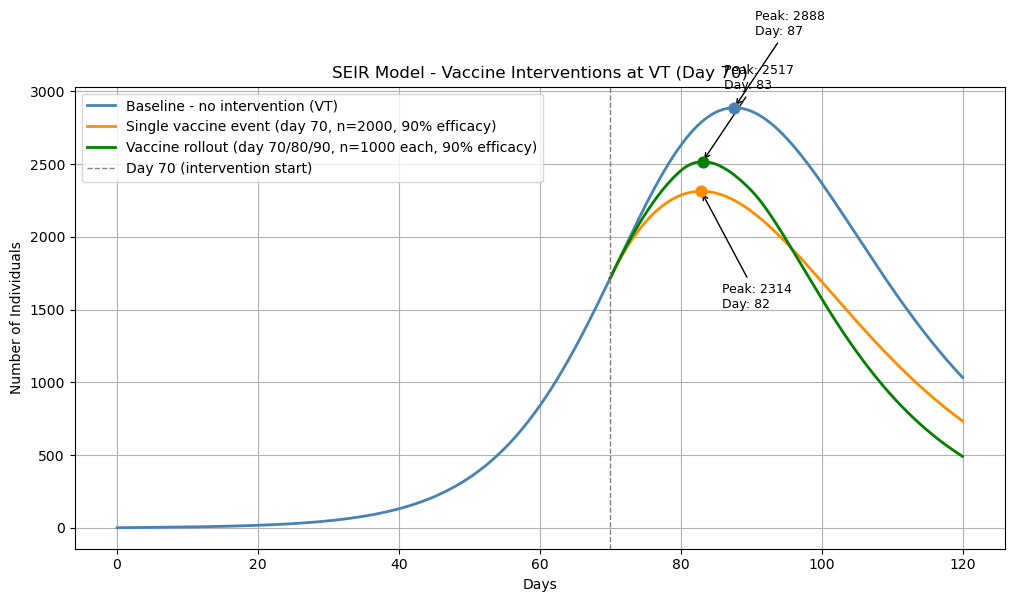

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


data = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)
data.columns = ['day', 'date', 'active_cases']
cases = data['active_cases'].values
days_data = data['day'].values

# Model parameters and initial conditions
N = 10000
S0 = 9990
E0 = 5
I0 = 5
R0 = 0
num_days = 120
dt = 0.1

# SEIR simulation function
def simulate_seir(params):
    beta, sigma, gamma = params
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]
    for _ in range(int(num_days/dt)):
        s, e, i, r = S[-1], E[-1], I[-1], R[-1]
        ds = -beta * s * i / N
        de = beta * s * i / N - sigma*e
        di = sigma*e - gamma*i
        dr = gamma*i
        S.append(max(s + ds*dt, 0))
        E.append(max(e + de*dt, 0))
        I.append(max(i + di*dt, 0))
        R.append(max(r + dr*dt, 0))
    return np.array(S), np.array(E), np.array(I), np.array(R)

# Objective function to minimize
def objective(params):
    _, _, I_sim, _ = simulate_seir(params)
    t_sim = np.linspace(0, num_days, len(I_sim))
    I_interp = np.interp(days_data, t_sim, I_sim)
    return np.sum((I_interp - cases)**2)

# Fit parameters
initial_guess = [0.27, 1/5, 1/7]
res = minimize(objective, initial_guess, bounds=[(0,1),(0,1),(0,1)])
beta_fit, sigma_fit, gamma_fit = res.x
print(f"Fitted parameters: beta={beta_fit:.4f}, sigma={sigma_fit:.4f}, gamma={gamma_fit:.4f}")

# Run fitted SEIR
S_fit, E_fit, I_fit, R_fit = simulate_seir([beta_fit, sigma_fit, gamma_fit])
t = np.linspace(0, num_days, len(S_fit))


# VT population parameters (from slide instructions)
N_vt = 10000
I0_vt = 1
R0_vt = 0
E0_vt = E0  # same E0 as UVA
S0_vt = N_vt - I0_vt - E0_vt - R0_vt

# Run VT baseline: reuse simulate_seir logic but with VT initial conditions
def simulate_seir_ic(params, N_pop, S_init, E_init, I_init, R_init, n_days):
    """Same Euler method as simulate_seir, but with custom initial conditions."""
    beta, sigma, gamma = params
    S = [S_init]; E = [E_init]; I = [I_init]; R = [R_init]
    for _ in range(int(n_days/dt)):
        s, e, i, r = S[-1], E[-1], I[-1], R[-1]
        ds = -beta * s * i / N_pop
        de =  beta * s * i / N_pop - sigma*e
        di =  sigma*e - gamma*i
        dr =  gamma*i
        S.append(max(s + ds*dt, 0))
        E.append(max(e + de*dt, 0))
        I.append(max(i + di*dt, 0))
        R.append(max(r + dr*dt, 0))
    return np.array(S), np.array(E), np.array(I), np.array(R)

# Baseline VT simulation days 0-120
S_vt, E_vt, I_vt, R_vt = simulate_seir_ic(
    [beta_fit, sigma_fit, gamma_fit], N_vt, S0_vt, E0_vt, I0_vt, R0_vt, n_days=120
)
t_vt = np.linspace(0, 120, len(I_vt))

# Snapshot SEIR state at day 70
idx_70 = int(70 / dt)
S70 = S_vt[idx_70]; E70 = E_vt[idx_70]; I70 = I_vt[idx_70]; R70 = R_vt[idx_70]

# --- Scenario 1: Single vaccine event on day 70 (n=2000, 90% efficacy)
S70_s1 = max(S70 - 0.90 * 2000, 0)
R70_s1 = R70 + 0.90 * 2000
_, _, I_single, _ = simulate_seir_ic(
    [beta_fit, sigma_fit, gamma_fit], N_vt, S70_s1, E70, I70, R70_s1, n_days=50
)
t_single = np.linspace(70, 120, len(I_single))

# --- Scenario 2: Rollout — 1000 on day 70, day 80, day 90 (90% efficacy each)
# Segment 1: day 70 dose, simulate to day 80
S70_r = max(S70 - 0.90 * 1000, 0)
R70_r = R70 + 0.90 * 1000
S_seg1, E_seg1, I_seg1, R_seg1 = simulate_seir_ic(
    [beta_fit, sigma_fit, gamma_fit], N_vt, S70_r, E70, I70, R70_r, n_days=10
)

# Segment 2: day 80 dose, simulate to day 90
S80_r = max(S_seg1[-1] - 0.90 * 1000, 0)
R80_r = R_seg1[-1] + 0.90 * 1000
S_seg2, E_seg2, I_seg2, R_seg2 = simulate_seir_ic(
    [beta_fit, sigma_fit, gamma_fit], N_vt, S80_r, E_seg1[-1], I_seg1[-1], R80_r, n_days=10
)

# Segment 3: day 90 dose, simulate to day 120
S90_r = max(S_seg2[-1] - 0.90 * 1000, 0)
R90_r = R_seg2[-1] + 0.90 * 1000
S_seg3, E_seg3, I_seg3, R_seg3 = simulate_seir_ic(
    [beta_fit, sigma_fit, gamma_fit], N_vt, S90_r, E_seg2[-1], I_seg2[-1], R90_r, n_days=30
)

# Stitch rollout segments together
I_rollout = np.concatenate([I_seg1, I_seg2[1:], I_seg3[1:]])
t_rollout = np.linspace(70, 120, len(I_rollout))

# Print summary
print(f"\n--- VT Vaccine Intervention Summary ---")
mask_70 = t_vt >= 70
print(f"Baseline peak I:     {np.max(I_vt[mask_70]):.0f} at day {t_vt[mask_70][np.argmax(I_vt[mask_70])]:.1f}")
print(f"Single-event peak I: {np.max(I_single):.0f} at day {t_single[np.argmax(I_single)]:.1f}")
print(f"Rollout peak I:      {np.max(I_rollout):.0f} at day {t_rollout[np.argmax(I_rollout)]:.1f}")

# Plot vaccine interventions
plt.figure(figsize=(12,6))
plt.plot(t_vt, I_vt, color='steelblue', linewidth=2, label='Baseline - no intervention (VT)')
plt.plot(t_single,  I_single,  color='darkorange', linewidth=2, label='Single vaccine event (day 70, n=2000, 90% efficacy)')
plt.plot(t_rollout, I_rollout, color='green',      linewidth=2, label='Vaccine rollout (day 70/80/90, n=1000 each, 90% efficacy)')
plt.axvline(70, color='gray', linestyle='--', linewidth=1, label='Day 70 (intervention start)')

# Annotate peaks
for I_arr, t_arr, color, dy in [
    (I_vt[mask_70], t_vt[mask_70], 'steelblue',  500),
    (I_single,      t_single,      'darkorange', -800),
    (I_rollout,     t_rollout,     'green',       500),
]:
    pk_val = np.max(I_arr)
    pk_day = t_arr[np.argmax(I_arr)]
    plt.scatter(pk_day, pk_val, color=color, s=60, zorder=5)
    plt.annotate(
        f'Peak: {int(pk_val)}\nDay: {int(pk_day)}',
        xy=(pk_day, pk_val),
        xytext=(pk_day+3, pk_val+dy),
        arrowprops=dict(facecolor=color, arrowstyle='->'),
        fontsize=9
    )

plt.xlabel('Days')
plt.ylabel('Number of Individuals')
plt.title('SEIR Model - Vaccine Interventions at VT (Day 70)')
plt.legend()
plt.grid(True)
plt.show()

Fitted parameters:
beta = 0.2890110421523977
sigma = 0.14129473653422256
gamma = 0.06551893444129729


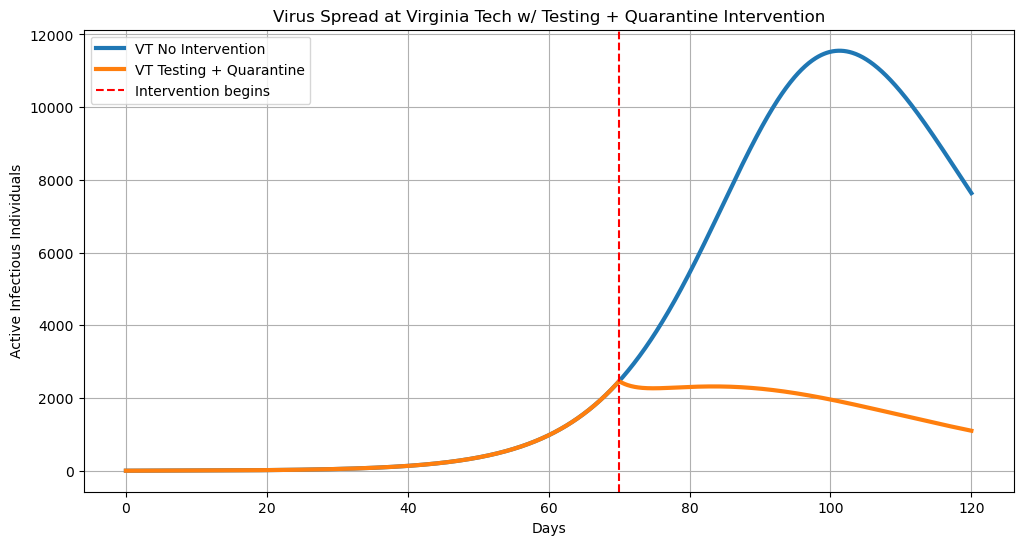

In [4]:
#Objective: implement testing + quarantine parameters starting from day 70 into the SEIR model and analyze their impact on the outbreak dynamics compared to the baseline scenario with no interventions.It will reduce the infectious period by 2 days

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


data = pd.read_csv(r'C:\\Users\\yancy\\OneDrive\\BME2315\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#3.csv')
data.columns = ['day','date','active_cases']

cases = data['active_cases'].values # number of infected people each day
days_data = data['day'].values # day numbers


#initial UVA parameters and conditions

N = 10000 # total population
S0 = 9990 # initially susceptible
E0 = 5 # initially exposed
I0 = 5 # initially infectious
R0 = 0 # initially recovered

num_days = 120 # number of days to simulate
dt = 0.1

#SEIR simulation function with optional testing + quarantine intervention starting from day 70
 
def simulate_seir(params):

    beta, sigma, gamma = params # extract the parameters from the input list

    S=[S0]
    E=[E0]
    I=[I0]
    R=[R0]

    for step in range(int(num_days/dt)):   # loop over time steps

        s = S[-1] 
        e = E[-1]
        i = I[-1]
        r = R[-1]

        ds = -beta*s*i/N  # change in susceptible
        de = beta*s*i/N - sigma*e  # change in exposed
        di = sigma*e - gamma*i  # change in infectious
        dr = gamma*i  # change in recovered

        S.append(max(s+ds*dt,0))  # update the compartment values using the Euler method and ensure they don't go negative
        E.append(max(e+de*dt,0))  
        I.append(max(i+di*dt,0))
        R.append(max(r+dr*dt,0))

    return np.array(S),np.array(E),np.array(I),np.array(R)


#Objective function to fit the model parameters to the UVA data using least squares on the infectious curve

def objective(params):  # objective function to minimize: sum of squared differences between model-predicted infectious and actual cases

    S_sim,E_sim,I_sim,R_sim = simulate_seir(params)  # run the SEIR simulation with the given parameters to get the predicted number of infectious individuals over time

    t_sim = np.linspace(0,num_days,len(I_sim))  # create a time array corresponding to the length of the simulation output

    I_interp = np.interp(days_data,t_sim,I_sim)  # interpolate the simulated infectious curve to match the actual data days, so we can compare them directly

    return np.sum((I_interp-cases)**2)  # return the sum of squared differences between the interpolated simulated infectious curve and the actual active cases, which is what we want to minimize

#fit the model parameters

initial_guess = [0.27,1/5,1/7]  # initial guesses for beta, sigma, gamma without the interventions 
result = minimize(objective,initial_guess,bounds=[(0,1),(0,1),(0,1)]) #

beta_fit,sigma_fit,gamma_fit = result.x # extract the fitted parameters from the optimization result

print("Fitted parameters:")  # print the fitted parameters for beta, sigma, and gamma
print("beta =",beta_fit)
print("sigma =",sigma_fit)
print("gamma =",gamma_fit)


#run UVA model with fitted parameters to get the predicted number of infectious individuals over time

S_fit,E_fit,I_fit,R_fit = simulate_seir([beta_fit,sigma_fit,gamma_fit])

t = np.linspace(0,num_days,len(S_fit))


#implement VT parameters and initial conditions

N = 40000
S0 = N - 1
E0 = 5
I0 = 1
R0 = 0


#Testing + quarantine intervention function that modifies the SEIR simulation to reduce the infectious period by 2 days starting from day 70

def simulate_testing_intervention(params):

    beta,sigma,gamma = params

    gamma_quarantine = 1/5   # infectious period reduced by 2 days due to testing + quarantine

    S=[S0]
    E=[E0]
    I=[I0]
    R=[R0]

    for step in range(int(num_days/dt)): 

        s = S[-1]
        e = E[-1]
        i = I[-1]
        r = R[-1]

        current_day = step*dt

        if current_day >= 70:
            gamma_effective = gamma_quarantine
        else:
            gamma_effective = gamma

        ds = -beta*s*i/N
        de = beta*s*i/N - sigma*e
        di = sigma*e - gamma_effective*i
        dr = gamma_effective*i

        S.append(max(s+ds*dt,0))
        E.append(max(e+de*dt,0))
        I.append(max(i+di*dt,0))
        R.append(max(r+dr*dt,0))

    return np.array(S),np.array(E),np.array(I),np.array(R)  # return the arrays for susceptible, exposed, infectious, and recovered individuals over time from the modified SEIR simulation with testing + quarantine intervention

#Run the SEIR simulation for both the baseline scenario (no intervention) and the testing + quarantine intervention scenario using the fitted parameters for VTech

S_vt,E_vt,I_vt,R_vt = simulate_seir([beta_fit,sigma_fit,gamma_fit])

S_vt_test,E_vt_test,I_vt_test,R_vt_test = simulate_testing_intervention(
[beta_fit,sigma_fit,gamma_fit])


#Plotting the results 

t = np.linspace(0,num_days,len(S_vt))

plt.figure(figsize=(12,6))

plt.plot(t,I_vt,label="VT No Intervention",linewidth=3)

plt.plot(t,I_vt_test,label="VT Testing + Quarantine",linewidth=3)

plt.axvline(x=70,color='red',linestyle='--',label="Intervention begins")

plt.xlabel("Days")
plt.ylabel("Active Infectious Individuals")

plt.title("Virus Spread at Virginia Tech w/ Testing + Quarantine Intervention")

plt.legend()
plt.grid(True)

plt.show()

Fitted parameters:
beta = 0.2890110421523977
sigma = 0.14129473653422256
gamma = 0.06551893444129729


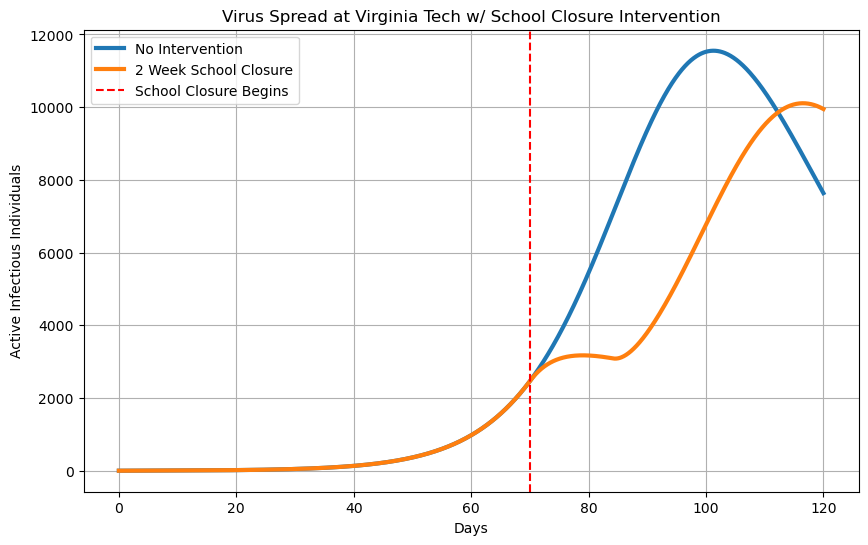

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Load UVA data 

data = pd.read_csv(r'C:\\Users\\yancy\\OneDrive\\BME2315\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#3.csv',
parse_dates=['date'])

data.columns = ['day','date','active_cases']

cases = data['active_cases'].values
days_data = data['day'].values


#Input same initial parameters and conditions as UVA for fitting the model to their data

N = 10000
S0 = 9990
E0 = 5
I0 = 5
R0 = 0

num_days = 120
dt = 0.1


# Simulate the SEIR model using the Euler method with the given parameters and initial conditions, and return the time series of each compartment as numpy arrays

def simulate_seir(params):  # function to simulate the SEIR model using the Euler method

    beta, sigma, gamma = params  # extract the parameters from the input list

    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]

    for step in range(int(num_days/dt)):  

        s = S[-1]
        e = E[-1]
        i = I[-1]
        r = R[-1]

        ds = -beta*s*i/N  # change in susceptible population
        de = beta*s*i/N - sigma*e  # change in exposed population
        di = sigma*e - gamma*i  # change in infectious population
        dr = gamma*i   # change in recovered population

        S.append(max(s+ds*dt,0))  # update the compartment values using the Euler method and ensure they don't go negative
        E.append(max(e+de*dt,0))
        I.append(max(i+di*dt,0))
        R.append(max(r+dr*dt,0))

    return np.array(S), np.array(E), np.array(I), np.array(R)  # return the time series of each compartment as numpy arrays


# Define an objective function to fit the model parameters to the UVA data using least squares on the infectious curve, which will be minimized by the optimization algorithm

def objective(params):  # objective function to minimize: sum of squared differences between model-predicted infectious and actual cases

    S_sim,E_sim,I_sim,R_sim = simulate_seir(params)  # run the SEIR simulation with the given parameters to get the predicted number of infectious individuals over time

    t_sim = np.linspace(0,num_days,len(I_sim))  # create a time array corresponding to the length of the simulation output

    I_interp = np.interp(days_data,t_sim,I_sim)  # interpolate the simulated infectious curve to match the actual data days, so we can compare them directly

    return np.sum((I_interp-cases)**2)  # return the sum of squared differences between the interpolated simulated infectious curve and the actual active cases, which is what we want to minimize


# Fit the model parameters by minimizing the objective function using an optimization algorithm, starting from an initial guess for the parameters

initial_guess = [0.27,1/5,1/7]  # initial guesses for beta, sigma, gamma without the interventions

result = minimize(objective,initial_guess,bounds=[(0,1),(0,1),(0,1)])   # minimize the objective function with respect to the parameters, with bounds to ensure they stay within a reasonable range

beta_fit,sigma_fit,gamma_fit = result.x  # extract the fitted parameters from the optimization result

print("Fitted parameters:")
print("beta =",beta_fit)
print("sigma =",sigma_fit)
print("gamma =",gamma_fit)


#Implement VTech parameters and initial conditions for the SEIR model, and simulate the baseline outbreak without any interventions using the fitted parameters to get the predicted number of infectious individuals over time

N = 40000  # Total population size for Virginia Tech (larger than UVA's 10,000 to reflect the larger campus population)
S0 = N - 1
E0 = 5
I0 = 1
R0 = 0


#Baseline simulation for Virginia Tech with fitted parameters

S_vt,E_vt,I_vt,R_vt = simulate_seir([beta_fit,sigma_fit,gamma_fit])  # run the SEIR simulation for Virginia Tech using the fitted parameters to get the predicted number of susceptible, exposed, infectious, and recovered individuals over time

t = np.linspace(0,num_days,len(S_vt))  # create a time array corresponding to the length of the simulation output for plotting


# Now implement the school closure intervention in the SEIR model 

def simulate_school_closure(params): # function to simulate the SEIR model with a school closure intervention

    beta,sigma,gamma = params

    closure_start = 70  #intial school closure day
    closure_end = 84   # 2 weeks later

    S=[S0]
    E=[E0]
    I=[I0]
    R=[R0]

    for step in range(int(num_days/dt)):

        s=S[-1]
        e=E[-1]
        i=I[-1]
        r=R[-1]

        current_day = step*dt

        # reduce contacts during closure
        if closure_start <= current_day <= closure_end:
            beta_effective = beta * 0.2  # assume 80% reduction in transmission during school closure
        else:
            beta_effective = beta  # normal transmission rate outside of closure period

        ds = -beta_effective*s*i/N
        de = beta_effective*s*i/N - sigma*e
        di = sigma*e - gamma*i
        dr = gamma*i

        S.append(max(s+ds*dt,0))
        E.append(max(e+de*dt,0))
        I.append(max(i+di*dt,0))
        R.append(max(r+dr*dt,0))

    return np.array(S),np.array(E),np.array(I),np.array(R)  # return the arrays for susceptible, exposed, infectious, and recovered individuals over time from the modified SEIR simulation with school closure intervention


S_vt_close,E_vt_close,I_vt_close,R_vt_close = simulate_school_closure(
[beta_fit,sigma_fit,gamma_fit])


#Plotting the results of the baseline scenario (no intervention) and the school closure intervention scenario for Virginia Tech

plt.figure(figsize=(10,6))

plt.plot(t,I_vt,label="No Intervention",linewidth=3)

plt.plot(t,I_vt_close,label="2 Week School Closure",linewidth=3)

plt.axvline(x=70,color='red',linestyle='--',label="School Closure Begins")

plt.xlabel("Days")
plt.ylabel("Active Infectious Individuals")

plt.title("Virus Spread at Virginia Tech w/ School Closure Intervention")   

plt.legend()
plt.grid(True)

plt.show()

## Verify and validate your analysis: 


https://www.techscience.com/CMES/v137n3/53721/html

In this research paper from The Department of Mathematics and Statistics, College of Science, Imam Mohammad Ibn Saud Islamic University, Riyadh, 11566, Saudi Arabia, they analyzed the effects of vaccines on the spread of coronavirus. Without vaccinations, they found that roughly 18% of a population was infected at the peak date. With 35% of the poplulation receiving vaccines, this number dropped to roughly 15% at the peak date. When the vaccination percent increases to 60-90% of the suceptible population, this number drops off completely and the spread is insignificant.

In our findings, the model estimated ~29% of our suceptible population would be infected at the peak of the influenza virus. However, with 2000 vaccines administered at 90% efficacy (18% of the population successfully vaccinated), the number drops to ~23% of the population infected at the peak date. Our numbers are relatively close to the values given in the paper, with differences likely lying in discrepancies of R0, beta, gamma, and/or sigma value differences between the two diseases.

https://pubmed.ncbi.nlm.nih.gov/34815624/ 



*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*